In [1]:
import torch
import math
from monte_carlo import MonteCarloIntegration
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **Integración Monte Carlo**

In [3]:
class AntitheticMonteCarloIntegration:

    def __init__(self, function, device="cpu"):
        
        self.device = device
        self.function = function
        self.Z_norm = torch.distributions.Normal(0, 1)

    def compute_integral(self, a, b, n=100, alpha=0.05):

        u = torch.rand((n,)).to(self.device)

        x = a + (b-a)*u

        x_ = a + (b-a)*(1-u)

        alpha_t = torch.tensor([1-alpha/2], device=self.device)

        z_alpha = self.Z_norm.icdf(alpha_t).item()

        values = (self.function(x) + self.function(x_))/2

        integral = ((b-a) * values.mean()).item()

        se = (b-a) * values.std().item() / math.sqrt(n)

        conf_int = (integral - z_alpha*se, integral + z_alpha*se)

        print(
            "integral: {:.4f}, Confidence Interval: ({:.4f}, {:.4f}), Var: {:.4f}"
            .format(integral, conf_int[0], conf_int[1], se**2)
        )

        return integral, conf_int, se

In [4]:
def F(x):

    return torch.exp(x**2)

In [5]:
mc_int = MonteCarloIntegration(F)
inte, ci, var = mc_int.compute_integral(2, 3, n=1000000)

integral: 1425.9025, Confidence Interval: (1422.1889, 1429.6160), Var: 3.5899


In [6]:
amc_int = AntitheticMonteCarloIntegration(F, device=device)
inte, ci, var = amc_int.compute_integral(2, 3, n=1000000)

integral: 1427.4558, Confidence Interval: (1425.5566, 1429.3550), Var: 0.9389


In [7]:
mc_int = MonteCarloIntegration(F)
mc_int.compute_integral(-1, 1, n=1000000)

integral: 2.9249, Confidence Interval: (2.9230, 2.9267), Var: 0.0000


(2.9248592853546143,
 (2.922999375751205, 2.9267191949580234),
 9.00507559171274e-07)

In [8]:
amc_int = AntitheticMonteCarloIntegration(F, device=device)
amc_int.compute_integral(-1, 1, n=1000000)

integral: 2.9258, Confidence Interval: (2.9240, 2.9277), Var: 0.0000


(2.925837993621826,
 (2.9239791413831586, 2.9276968458604937),
 0.0009484112858772277)

In [9]:
class StratifiedMonteCarloIntegration:

    def __init__(self, function, device="cpu"):
        
        self.device = device
        self.function = function
        self.Z_norm = torch.distributions.Normal(0, 1)
        self.U_s = None

    def compute_integral(self, a, b, S=10, n=10000, alpha=0.05):

        a_u = torch.arange(0.0, 1.0, 1/S).to(self.device)
        b_u = torch.arange(1/S, 1.0 + 1/S, 1/S).to(self.device)
        
        self.U_s = torch.distributions.Uniform(a_u, b_u)
        u_s = self.U_s.sample((n,))

        x_s = (b-a)*self.function((a + (b-a)*u_s))
        p_s = 1 / S

        mu_s = torch.mean(x_s, dim=0)

        integral = torch.sum(p_s * mu_s).item()

        var_s = torch.var(x_s, dim=0)

        var = torch.sum((p_s**2) * var_s/n).item()

        se = math.sqrt(var)

        alpha_t = torch.tensor([1-alpha/2], device=self.device)
        z_alpha = self.Z_norm.icdf(alpha_t).item()

        conf_int = (integral - z_alpha*se, integral + z_alpha*se)
        print(
            "integral: {:.4f}, Confidence Interval: ({:.4f}, {:.4f}), Var: {:.4f}"
            .format(integral, conf_int[0], conf_int[1], var)
        )

        return integral, conf_int, var

In [10]:
smc_int = StratifiedMonteCarloIntegration(F, device=device)
_, _, _ = smc_int.compute_integral(2, 3, n=1000000)

integral: 1428.1938, Confidence Interval: (1427.9510, 1428.4367), Var: 0.0153


# **Aproximación de $\pi$**

In [11]:
class PiMonteCarlo:

    def __init__(self, device="cpu"):
        self.device = device
        self.U = torch.distributions.Uniform(0, 1)

    def compute_pi(self, n=10000, decimals=4):
        """
        Estimador Monte Carlo básico usando
        X = 4 * 1{U1^2 + U2^2 <= 1}
        """
        U = self.U.sample((n, 2)).to(self.device)

        indicator = (U[:, 0]**2 + U[:, 1]**2 <= 1).float()
        X = 4 * indicator
        pi_hat = torch.mean(X)
        var_hat = torch.var(X)/n

        print(f"Estimación de π (MC): {pi_hat.item():.{decimals}f}")
        print(f"Varianza estimada: {var_hat.item():.{decimals}f}")

        return pi_hat.item(), var_hat.item()

    def compute_pi_control(self, n=10000, decimals=4):
        """
        Estimador usando variable de control
        W = 1{U1 + U2 > 2 - sqrt(2)}
        """
        U = self.U.sample((n, 2)).to(self.device)

        # Variable X
        indicator = (U[:, 0]**2 + U[:, 1]**2 <= 1).float()
        X = 4 * indicator

        # Variable de control
        W = (U[:, 0] + U[:, 1] > math.sqrt(2)).float()

        # Esperanza teorica de W
        EW = 3 - 2*math.sqrt(2)

        # medias
        X_bar = torch.mean(X)
        W_bar = torch.mean(W)

        # covarianza y varianza
        cov_XW = torch.mean((X - X_bar)*(W - W_bar))
        var_W = torch.var(W)

        # coeficiente optimo
        c = cov_XW / var_W

        # estimador control variate
        pi_cv = X_bar - c*(W_bar - EW)

        # varianza estimada
        Y = X - c*(W - EW)
        var_hat = torch.var(Y) / n

        print(f"Estimación de π (Control Variate): {pi_cv.item():.{decimals}f}")
        print(f"Varianza estimada: {var_hat.item():.{decimals}f}")

        return pi_cv.item(), var_hat.item()

    def compute_pi_conditional(self, n=10000, decimals=4):
        """
        Estimador Monte Carlo condicional
        X_cond = E[X|U1] = 4*sqrt(1 - U1^2)
        """
        
        U1 = self.U.sample((n,)).to(self.device)
        X_cond = 4 * torch.sqrt(1 - U1**2)
        
        pi_hat = torch.mean(X_cond)
        
        var_hat = torch.var(X_cond) / n
        
        print(f"Estimación de π (Conditional MC): {pi_hat.item():.{decimals}f}")
        print(f"Varianza estimada: {var_hat.item():.{decimals}f}")
    
        return pi_hat.item(), var_hat.item()
        
    def compute_pi_stratified(self, S=10, n=10000, decimals=4):
        """
        Estimación de π usando muestreo estratificado en U1
        """
    
        a = torch.arange(0.0, 1.0, 1/S).to(self.device)
        b = torch.arange(1/S, 1.0 + 1/S, 1/S).to(self.device)
    
        Unif_s = torch.distributions.Uniform(a, b)
    
        # U1 estratificado
        U_s = Unif_s.sample((n,))**2
    
        # U2 uniforme
        U = self.U.sample((n, 1)).to(self.device)**2
    
        X_S = (U_s + U) <= 1
        X = 4 * X_S.float()
    
        # estimación de μ_s
        mu_s = torch.mean(X, dim=0)
    
        p_s = 1 / S
        pi_hat = torch.sum(p_s * mu_s)
    
        # varianza
        var_s = torch.var(X, dim=0)
        
        var_hat = torch.sum((p_s**2) * var_s/n)
    
        print(f"Estimación de π (Stratified MC): {pi_hat.item():.{decimals}f}")
        print(f"Varianza estimada: {var_hat.item():.{decimals}f}")
    
        return pi_hat.item(), var_hat.item()

    def compare_variances(self, n=10000, S=10):
        """
        Grafica las varianzas de los diferentes estimadores de π
        """
    
        _, var_mc = self.compute_pi(n=n)
        _, var_cv = self.compute_pi_control(n=n)
        _, var_cond = self.compute_pi_conditional(n=n)
        _, var_strat = self.compute_pi_stratified(S=S, n=n)
    
        names = [
            "Monte Carlo",
            "Control Variate",
            "Conditional MC",
            "Stratified MC"
        ]
    
        vars_ = [var_mc, var_cv, var_cond, var_strat]
    
        plt.figure(figsize=(8,5))
        plt.bar(names, vars_)
        plt.ylabel("Varianza estimada")
        plt.title("Comparación de reducción de varianza en estimación de π")
        plt.xticks(rotation=20)
        plt.show()

In [12]:
PI_MC = PiMonteCarlo(device=device)

pi_mc, var_mc = PI_MC.compute_pi(n=10000000, decimals=10)

Estimación de π (MC): 3.1418471336
Varianza estimada: 0.0000002696


In [13]:
pi_cv, var_cv = PI_MC.compute_pi_control(n=10000000, decimals=10)

Estimación de π (Control Variate): 3.1414091587
Varianza estimada: 0.0000000653


In [14]:
pi_cv, var_cv = PI_MC.compute_pi_conditional(n=10000000, decimals=10)

Estimación de π (Conditional MC): 3.1415109634
Varianza estimada: 0.0000000797


In [15]:
pi_cv, var_cv = PI_MC.compute_pi_stratified(n=10000000, decimals=10)

Estimación de π (Stratified MC): 3.1418967247
Varianza estimada: 0.0000000192


Estimación de π (MC): 3.1407
Varianza estimada: 0.0000
Estimación de π (Control Variate): 3.1421
Varianza estimada: 0.0000
Estimación de π (Conditional MC): 3.1415
Varianza estimada: 0.0000
Estimación de π (Stratified MC): 3.1404
Varianza estimada: 0.0000


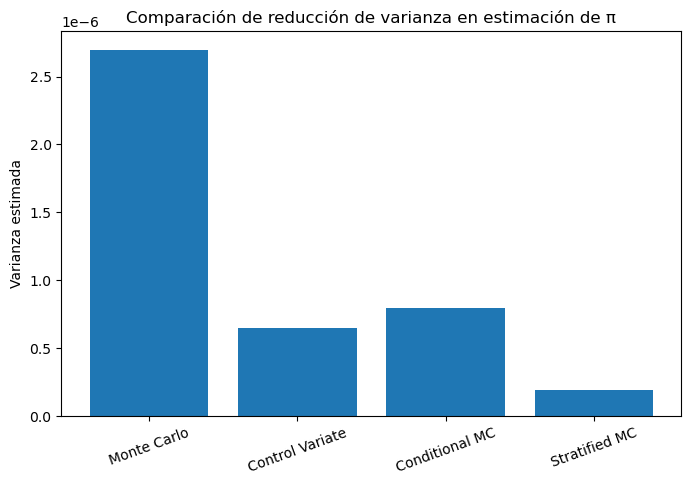

In [16]:
PI_MC.compare_variances(n=1000000)

# **Monte Carlo Multivariado**

In [17]:
class NormalMultivariateMonteCarlo:

    def __init__(self, mu, Sigma, f, device="cpu"):

        self.device = device

        self.mu = mu.to(device)
        self.Sigma = Sigma.to(device)

        # Cholesky
        self.L = torch.linalg.cholesky(self.Sigma)

        self.d = self.mu.shape[0]

        self.f = f

    def monte_carlo(self, n=10000, decimals=6):
        """
        Monte Carlo estándar
        """

        Z = torch.randn(n, self.d).to(self.device)

        X = self.mu + Z @ self.L.T

        FX = self.f(X)

        mean = torch.mean(FX)
        var = torch.var(FX) / n

        print(f"Esperanza estimada (MC): {mean.item():.{decimals}f}")
        print(f"Varianza estimada: {var.item():.{decimals}f}")

        return mean.item(), var.item()

    def antithetic(self, n=10000, decimals=6):
        """
        Monte Carlo con variables antitéticas
        """

        Z = torch.randn(n, self.d).to(self.device)

        X1 = self.mu + Z @ self.L.T
        X2 = self.mu - Z @ self.L.T

        f1 = self.f(X1)
        f2 = self.f(X2)

        estimator = (f1 + f2) / 2

        mean = torch.mean(estimator)
        var = torch.var(estimator) / n

        print(f"Esperanza estimada (Antithetic MC): {mean.item():.{decimals}f}")
        print(f"Varianza estimada: {var.item():.{decimals}f}")

        return mean.item(), var.item()

    def compare_variances(self, n=10000, figsize=(10, 6)):

        _, var_mc = self.monte_carlo(n=n)
        _, var_ant = self.antithetic(n=n)
    
        methods = ["Monte Carlo", "Antithetic MC"]
        variances = [var_mc, var_ant]
    
        plt.figure(figsize=figsize)
        plt.bar(methods, variances)
        plt.ylabel("Varianza estimada")
        plt.title("Comparación de varianza")
        plt.show()


In [18]:
mu = torch.tensor([0.5, -0.3])

Sigma = torch.tensor([
    [1.0, 0.6],
    [0.6, 1.5]
])

def G(X):
    return X[:, 0]**2 + X[:, 1]**2-2.5 * X[:, 0]*X[:, 1]

Esperanza estimada (MC): 1.718353
Varianza estimada: 0.000009
Esperanza estimada (Antithetic MC): 1.711057
Varianza estimada: 0.000005


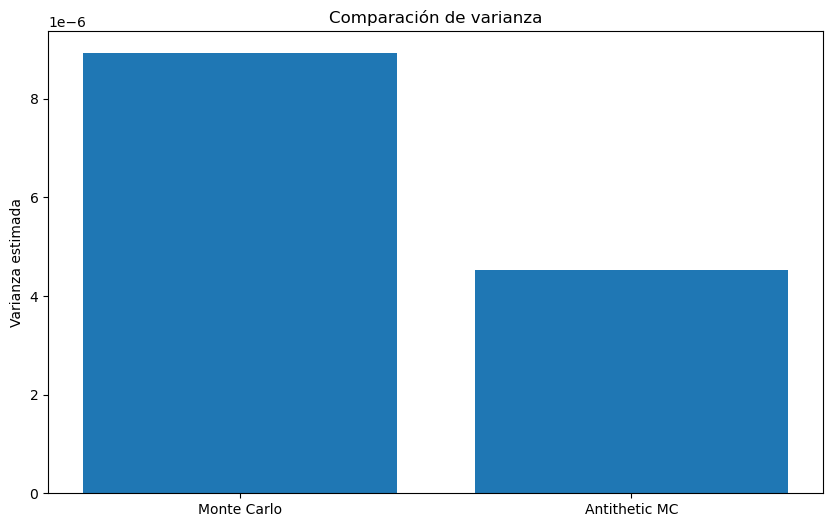

In [19]:
mc_normal = NormalMultivariateMonteCarlo(mu, Sigma, G, device=device)
mc_normal.compare_variances(n=1000000)

Esperanza estimada (MC): 0.263473
Varianza estimada: 0.000000
Esperanza estimada (Antithetic MC): 0.263972
Varianza estimada: 0.000000


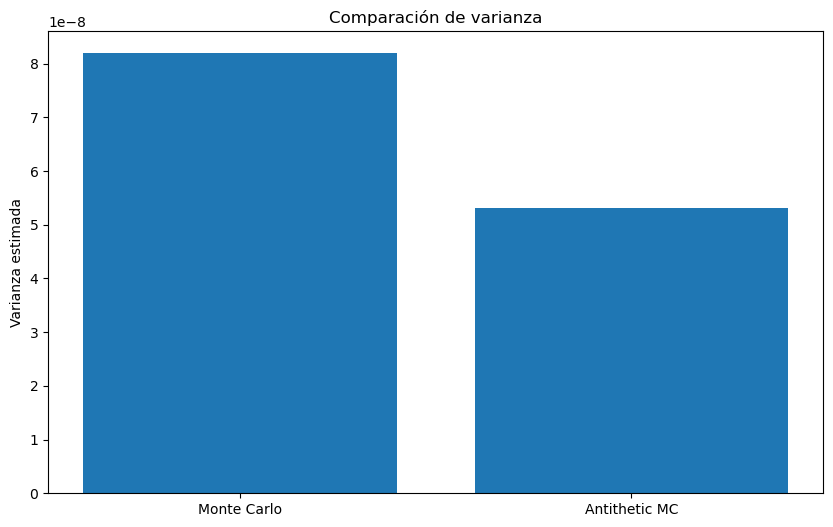

In [20]:
def G(X):
    return torch.exp(-X[:, 0]**2-X[:, 1]**2)
    
mc_normal = NormalMultivariateMonteCarlo(mu, Sigma, G, device=device)

mc_normal.compare_variances(n=1000000)